# Simple Moving Average Strategy

### Manan Verma

### 23 May 2026

In [11]:
import yfinance as yf
import matplotlib.pyplot as plt
from math import sqrt

First, the 5-year historical price data for *Microsoft* (MSFT) will be visualized:

[*********************100%***********************]  1 of 1 completed


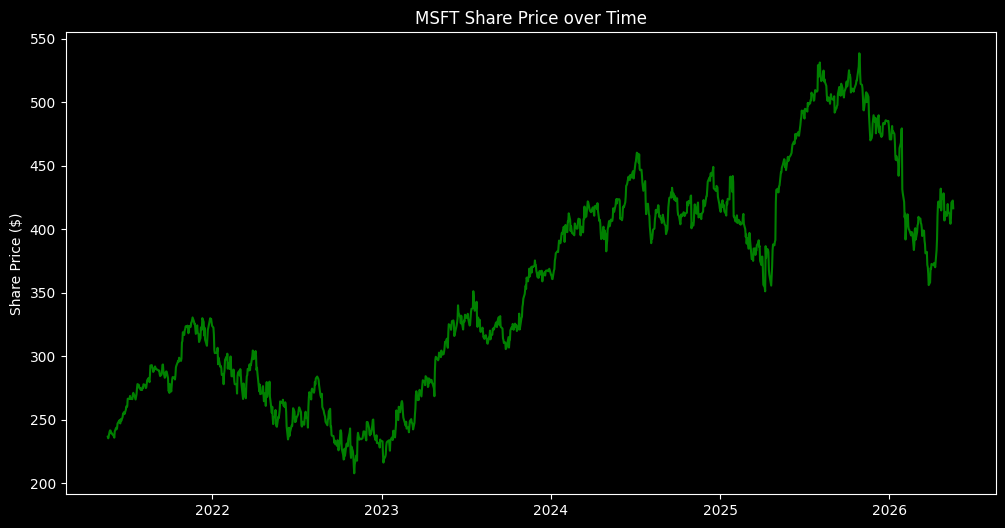

In [12]:
#Download MSFT historical share price and plot it

msft_data = yf.download("msft", start = '2021-05-20', end = '2026-05-20')
msft_close_prices = msft_data['Close']

#Plot the share price over time
plt.style.use("dark_background")
plt.figure(figsize = (12, 6))
plt.plot(msft_close_prices, color = 'green')
plt.ylabel("Share Price ($)")
plt.title("MSFT Share Price over Time")
plt.show()

Now, a short and a long simple moving average will be calculated and plotted against the share price.

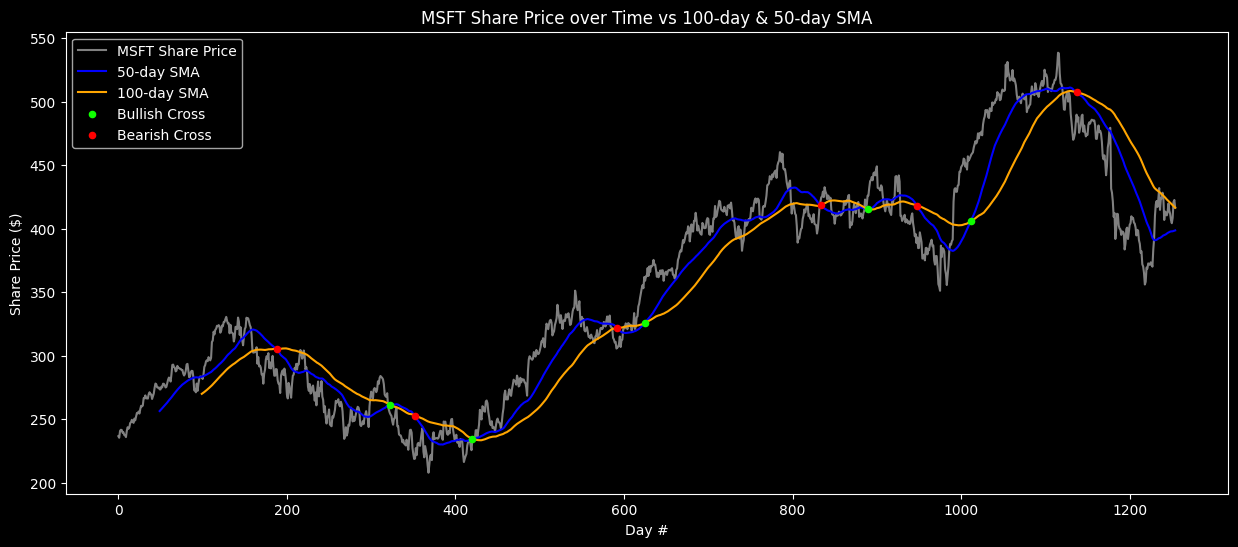

In [13]:
#Create and plot a long and short SMA

def create_sma(price_data, length):
    """Creates an SMA for the inputted price data of the specified length.
       Takes as input the stock price data as a list and the desired length of the SMA, 
       outputs a list with data points of the SMA"""
    sma = []

    if (length >= len(price_data)):
        raise ValueError("Specified length of SMA exceeds amount of price data")
    
    for i in range(length, len(price_data) + 1):
        sma.append(sum(price_data[i - length : i]) / length)

    return sma

def find_crossovers(short, long, short_length, long_length):
    """Finds all points at which the long SMA and the short SMA cross, whether its bullish or bearish.
       Takes in as input the short and long SMAs as lists and their respective lengths, 
       ouputs a list of two lists: one with all bullish crossover points, and one with all bearish crossover points"""
    crossovers = [[], []]   #[ [*bullish*], [*bearish*] ]

    offset = long_length - short_length
    for i in range(1, len(long)):
        #Find Bullish Crossovers, i.e, when the short crosses above the long
        if ((short[i + offset - 1] < long[i - 1]) and (short[i + offset] >= long[i])):
            crossovers[0].append(i)

        #Find Bearish Crossovers, i.e, when the short crosses below the long
        if ((short[i + offset - 1] > long[i - 1]) and (short[i + offset] <= long[i])):
            crossovers[1].append(i)

    return crossovers

short_length = 50
long_length = 100

prices = msft_data['Close']['MSFT'].tolist()
sma_short = create_sma(prices, short_length)
sma_long = create_sma(prices, long_length)

x_price = range(len(prices))
x_short_sma = range(short_length - 1, len(prices))
x_long_sma = range(long_length - 1, len(prices))

crossovers = find_crossovers(sma_short, sma_long, short_length, long_length)
bullish_x = [i + long_length - 1 for i in crossovers[0]]
bearish_x = [i + long_length - 1 for i in crossovers[1]]
bullish_cross_prices = [sma_long[i] for i in crossovers[0]]
bearish_cross_prices = [sma_long[i] for i in crossovers[1]]

#Plot the two SMAs vs the Share Price
plt.style.use("dark_background")
plt.figure(figsize = (15, 6))
plt.plot(x_price, prices, color = 'grey', label = 'MSFT Share Price')
plt.plot(x_short_sma, sma_short, color = 'blue', label = f'{short_length}-day SMA')
plt.plot(x_long_sma, sma_long, color = 'orange', label = f'{long_length}-day SMA')
plt.scatter(bullish_x, bullish_cross_prices, s = 20, color = '#0fff00', zorder = 5, label = 'Bullish Cross')
plt.scatter(bearish_x, bearish_cross_prices, s = 20, color = '#ff0000', zorder = 5, label = 'Bearish Cross')
plt.legend()
plt.ylabel("Share Price ($)")
plt.xlabel('Day #')
plt.title(f"MSFT Share Price over Time vs {long_length}-day & {short_length}-day SMA")
plt.show()

The above graph overlays a long and short simple moving average on top of the share price, along with the locations and types of the crosses.  
A simple moving average (SMA) is the simplest type of moving average and is calculated by continuously averaging the price of the asset over the previous *n* days. Traders use SMAs to calculate general trends of an asset's price by smoothening out the noise. An SMA over a shorter period shows shorter term trends, and SMAs of longer durations show longer term, or macro, trends.  
When a short-term SMA crosses above a long-term SMA, that is usually considered a *bullish* signal since it can indicate upwards market momentum and thus rising prices; and vice versa for when the short-terms SMA crosses below the long-term SMA, which is considered a *bearish* signal. This is the notion behind this strategy: the asset is **bought every at every *bullish* signal** and **sold at every *bearish* signal**.  

*There are several downsides to using a simple moving average, which will be discussed at the end of this notebook, along with possible solutions.*

The strategy will be actually implemented below, and the equity curve will be plotted.

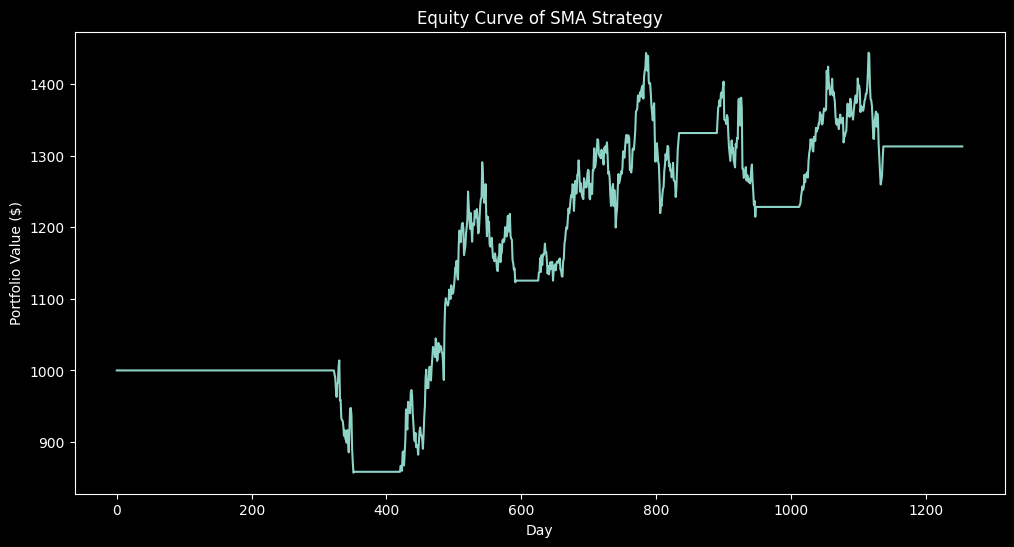

Final Portfolio Value: $1312.80
Final PnL: $312.80 (31.28%)


In [14]:
#Implement the SMA strategy

init_capital = 1000
equity_curve = [init_capital]
entry_days = bullish_x
exit_days = bearish_x

#Exiting the position can only happen after entering it
if (exit_days[0] < entry_days[0]):
    del(exit_days[0])

#Exit on the last day, if not already exited
if (entry_days[-1] > exit_days[-1]):
    exit_days.append(len(prices) - 1)

holding_position = False
current_capital = init_capital
current_trade = 0

for i in range (1, len(prices)):    
    #Enter Trade
    if (current_trade < len(entry_days) and entry_days[current_trade] == i):
        holding_position = True
        entry_price = prices[i]

    #Update Position
    if (holding_position):
        equity_curve.append(current_capital * (prices[i] / entry_price))
    else:
        equity_curve.append(equity_curve[i - 1])

    #Exit Trade
    if(current_trade < len(entry_days) and exit_days[current_trade] == i):
        holding_position = False
        current_trade += 1
        current_capital = equity_curve[i]

#Plot the Equity Curve
plt.figure(figsize = (12,6))
plt.style.use('dark_background')
plt.plot(equity_curve)
plt.title("Equity Curve of SMA Strategy")
plt.xlabel("Day")
plt.ylabel("Portfolio Value ($)")
plt.show()

print(f'Final Portfolio Value: ${equity_curve[-1]:.2f}')
print(f'Final PnL: ${equity_curve[-1] - init_capital:.2f} ({100 * (equity_curve[-1] - init_capital) / init_capital:.2f}%)')

To evaluate the strategy, the Sharpe Ratio will be calculated.

In [15]:
#Calculate the Sharpe Ratio of the Equity Curve above

def calculate_sharpe(equity_curve):
   '''Calculate the Sharpe Ratio of the given return series.
      Takes in as input the return series, outputs the Sharpe Ratio'''
   daily_risk_free_rate = 0.045 / 252  #Annual RFR = 4.5%, there are 252 trading days in a year
   
   daily_returns = [(equity_curve[i] / equity_curve[i - 1]) - 1 for i in range(1, len(equity_curve))]
   daily_excess_returns = [x - daily_risk_free_rate for x in daily_returns]
   mean_return = sum(daily_excess_returns) / len(daily_excess_returns)
   stdev_return = sqrt(sum([(x - mean_return)**2 for x in daily_excess_returns]) / (len(daily_excess_returns) - 1))

   return (sqrt(252) * mean_return / stdev_return)

print(f"Sharpe Ratio: {calculate_sharpe(equity_curve):.3f}")

Sharpe Ratio: 0.140


*The theory behind the Sharpe Ratio will be discussed towards the end of this notebook.*

Now, this strategy will be generalized to be used for any stock.

[*********************100%***********************]  1 of 1 completed


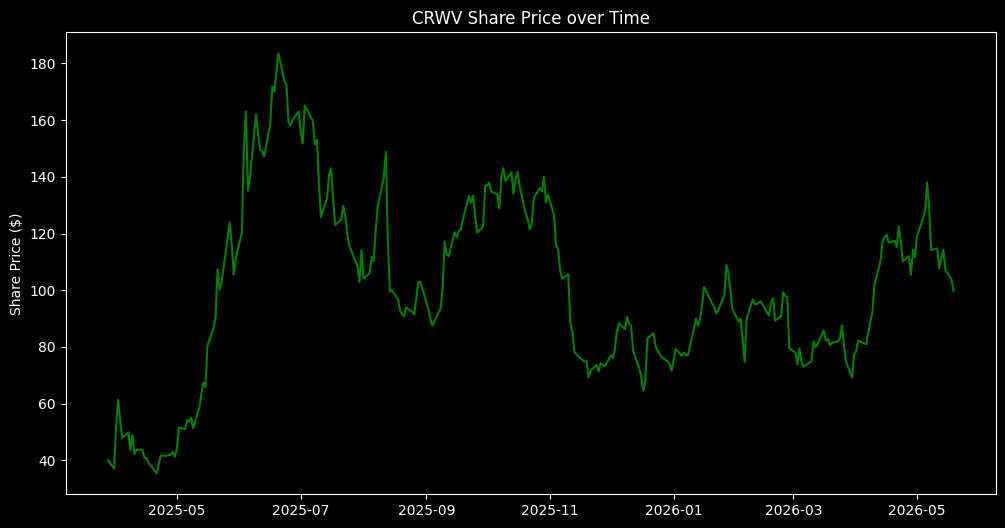

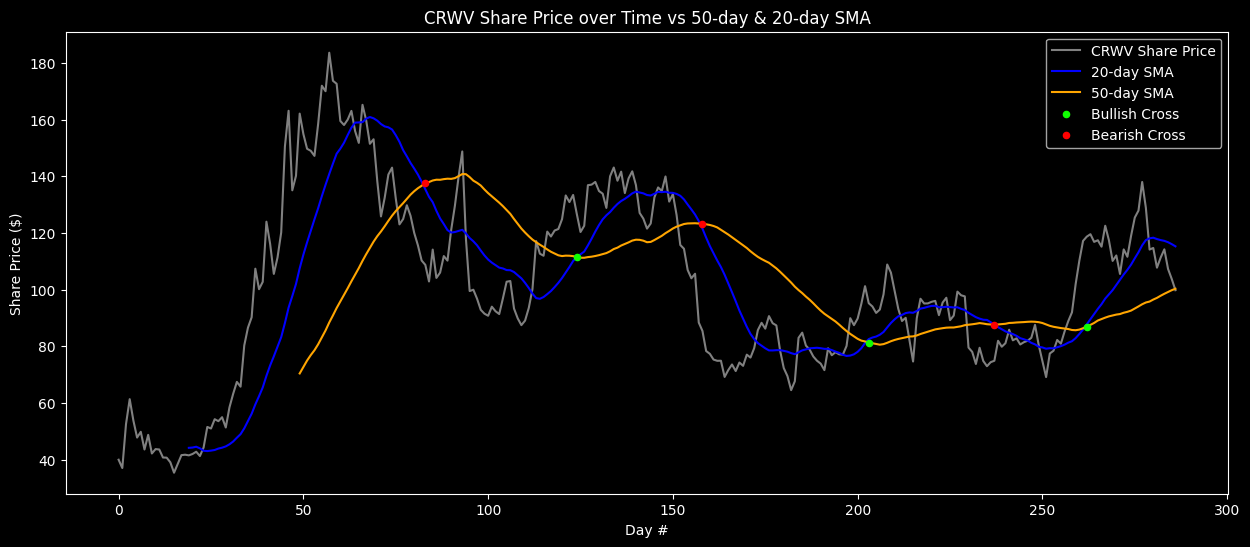

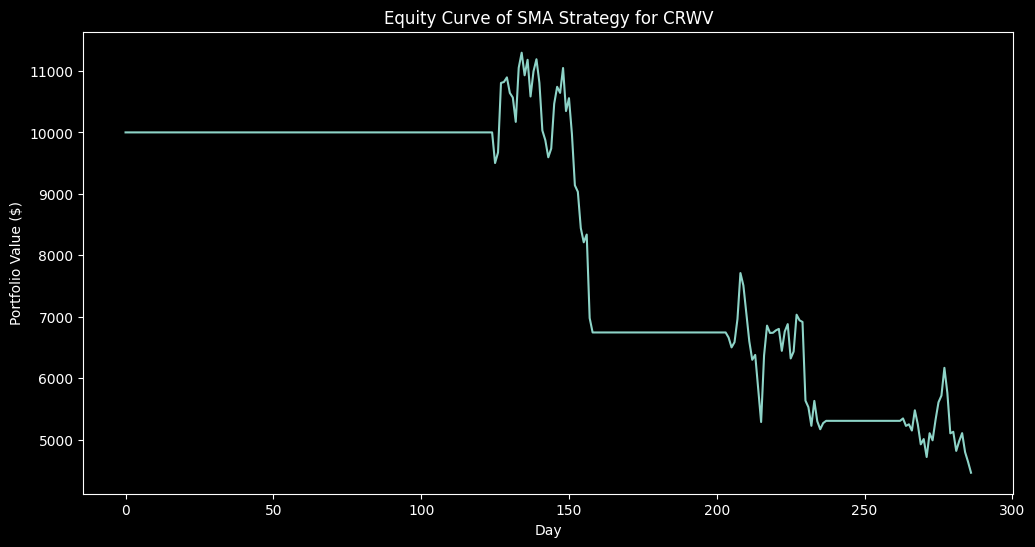

Final Portfolio Value: $4462.73
Final PnL: $-5537.27 (-55.37%)
Sharpe Ratio: -1.154


In [16]:
#Implement SMA strategy for user-chosen stock

#User chooses the stock ticker
stock = input("Type a stock to be analyzed: ")
stock_data = yf.download(stock, start = '2021-05-20', end = '2026-05-20')
while (stock_data.empty):
    stock = input("Type a stock to be analyzed: ")
    stock_data = yf.download(stock, start = '2021-05-20', end = '2026-05-20')

#User chooses lengths of SMAs
short_length = int(input("Short SMA length (must be 10, 20, 50, or 100 days): "))
while(short_length not in [10, 20, 50, 100]):
    short_length = int(input("Short SMA length (must be 10, 20, 50, or 100 days): "))
long_length = int(input("Long SMA length (must be 20, 50, 100, or 200 days): "))
while(long_length not in [20, 50, 100, 200] or long_length <= short_length):
    long_length = int(input("Long SMA length (must be 20, 50, 100, or 200 days): "))

#User chooses initial capital
init_capital = float(input("Initial capital ($): "))
while(init_capital <= 0):
    init_capital = float(input("Initial capital must be poistive: "))

#Visualize raw price data
plt.style.use("dark_background")
plt.figure(figsize = (12, 6))
plt.plot(stock_data['Close'], color = 'green')
plt.ylabel("Share Price ($)")
plt.title(f"{stock.upper()} Share Price over Time")
plt.show()

#Create SMAs
prices = stock_data['Close'][stock.upper()].tolist()
sma_short = create_sma(prices, short_length)
sma_long = create_sma(prices, long_length)

x_price = range(len(prices))
x_short_sma = range(short_length - 1, len(prices))
x_long_sma = range(long_length - 1, len(prices))

crossovers = find_crossovers(sma_short, sma_long, short_length, long_length)
bullish_x = [i + long_length - 1 for i in crossovers[0]]
bearish_x = [i + long_length - 1 for i in crossovers[1]]
bullish_cross_prices = [sma_long[i] for i in crossovers[0]]
bearish_cross_prices = [sma_long[i] for i in crossovers[1]]

#Plot the two SMAs vs the Share Price
plt.style.use("dark_background")
plt.figure(figsize = (15, 6))
plt.plot(x_price, prices, color = 'grey', label = f'{stock.upper()} Share Price')
plt.plot(x_short_sma, sma_short, color = 'blue', label = f'{short_length}-day SMA')
plt.plot(x_long_sma, sma_long, color = 'orange', label = f'{long_length}-day SMA')
plt.scatter(bullish_x, bullish_cross_prices, s = 20, color = '#0fff00', zorder = 5, label = 'Bullish Cross')
plt.scatter(bearish_x, bearish_cross_prices, s = 20, color = '#ff0000', zorder = 5, label = 'Bearish Cross')
plt.legend()
plt.ylabel("Share Price ($)")
plt.xlabel('Day #')
plt.title(f"{stock.upper()} Share Price over Time vs {long_length}-day & {short_length}-day SMA")
plt.show()

#Implement SMA strategy
equity_curve = [init_capital]
entry_days = bullish_x
exit_days = bearish_x

if (exit_days[0] < entry_days[0]):
    del(exit_days[0])

if (entry_days[-1] > exit_days[-1]):
    exit_days.append(len(prices) - 1)

holding_position = False
current_capital = init_capital
current_trade = 0

for i in range (1, len(prices)):    
    #Enter Trade
    if (current_trade < len(entry_days) and entry_days[current_trade] == i):
        holding_position = True
        entry_price = prices[i]

    #Update Position
    if (holding_position):
        equity_curve.append(current_capital * (prices[i] / entry_price))
    else:
        equity_curve.append(equity_curve[i - 1])

    #Exit Trade
    if(current_trade < len(entry_days) and exit_days[current_trade] == i):
        holding_position = False
        current_trade += 1
        current_capital = equity_curve[i]

#Plot the Equity Curve
plt.figure(figsize = (12,6))
plt.style.use('dark_background')
plt.plot(equity_curve)
plt.title(f"Equity Curve of SMA Strategy for {stock.upper()}")
plt.xlabel("Day")
plt.ylabel("Portfolio Value ($)")
plt.show()

print(f'Final Portfolio Value: ${equity_curve[-1]:.2f}')
print(f'Final PnL: ${equity_curve[-1] - init_capital:.2f} ({100 * (equity_curve[-1] - init_capital) / init_capital:.2f}%)')

#Evaluate strategy using Sharpe Ratio
print(f"Sharpe Ratio: {calculate_sharpe(equity_curve):.3f}")

### Sharpe Ratio
Essentially, the Sharpe Ratio calculates the *risk-adjusted returns* of an asset, portfolio, etc. The formula is shown below:

$$SR = \frac{\mathbb{E}[R_p - R_f]}{\sigma_p}$$
where $R_p$ is the portfolio's returns,  
$R_f$ is the risk-free returns,  
and $\sigma_p$ is the standard deviation of the excess returns ($R_p - R_f$).

First, the risk-free return (in this example, an annual risk-free return of 4.5% was used) is subtracted from the portfolio's returns, which is done in order to compare the portfolio to the benchmark (such as a US Treasury security). If the portfolio does not even outperform the benchmark, then no amount of risk justifies using the strategy in question.

Then, the excess returns (the portfolio's returns that are in excess of the risk-free returns) are normalized by its standard deviation. If a portfolio has a high standard deviation, the equity curve will not be smooth and there will be large deviations from the mean, including large bearish swings and periods of uncertainty. This is considered risky, as an investor would prefer as little uncertainty as possible- i.e., as close to a straight, upwards trend line as possible. Thus, a lower standard deviation will produce a higher Sharpe, and vice versa. This is the "risk-adjusted" part.

A Sharpe of less than **1.0** is considered sub-par, since the returns accumulated with respect to the risk do not justify the volatility taken on.  
A Sharpe of **1.0 - 1.9** is considered good.  
A Sharpe of **2.0 - 2.9** is considered excellent, and this is the range which many hedge funds lie in.

There are some limitations of the Sharpe Ratio, however. First, it assumes that returns are normally distributed. For example, that would mean that both upside and downside volatility are symmetric (the same) and normally distributed. In practice, this is mostly not the case. The normal distribution has very narrow tails of the same width and thus calculates extreme outcomes as statistically very rare. Though in reality, extreme outcomes are likely to be much more common, and the upside and downside likelihoods may not be the same. Another limitation is that the Sharpe Ratio cannot accurately compare differring asset classes, especially ones with different sampling frequencies (such as daily vs. monthly timeframes) or pricing methods (such as stocks vs. private equity). Finally, the Sharpe Ratio is backwards-looking, and is therefore not an accurate predictor of future returns.

### Moving Averages
A *Simple Moving Average* is calculated as follows:
$$SMA = \frac{1}{n} \sum_{i = 1}^{n}P_i$$
However, there are myriad issues with using this as a trading indicator. For one, it's a lagging indicator, meaning it only provides information about the past perfomance of the asset. So, if the underlying asset move dramatically, the signal could take a long while to catch up to what is currently happening. Not only that, but it also equally weights every historical data points, thus data from past regimes or data from when the asset behaved differently has equal weighting to the current, most up-to-date data.

To fix the second issue with the SMA, an *Exponential Moving Average* can be employed, which is calculated as follows:
$$EMA_n = \left(P_n \cdot \frac{\alpha}{1 + N}\right) + \left(EMA_{n - 1} \cdot \left(1 - \frac{\alpha}{1 + N}\right)\right)$$
where $EMA_n$ is the $EMA$'s present value, and $EMA_{n-1}$ is the $EMA$'s past value,    
$P_n$ is the asset's current price,    
$N$ is the time period of the $EMA$,  
and $\alpha$ is the smoothening factor, a larger $\alpha$ gives recent prices more weightage.  
An EMA gives a greater, exponential weightage to more recent data points, making it more sensitive to price changes that occur closer to the present. However, this characteristic of the EMA could also be a drawback: sudden, short-terms spikes can significantly distort the signal. Furthermore, the exponential nature of the EMA means that, even though there is a smooth decay, the EMA never truly "forgets" old data.

To fix the second issue with the EMA, a *Weighted Moving Average* can be employed, which is calculated as follows:
$$WMA_n = \frac{\sum_{i = 1}^n w_iP_i}{\sum_{i = 1}^nw_i}$$
where $n$ is the lookback period,  
$P_i$ is the underlying's price at point $i$,  
and $w_i$ is the weight associated with point $i$.  
The weights are typically assigned in a linearly declining nature such that recent data points are, again, given more importance. However, there is now a strict cut-off for using historical data, leaving no impact from the past which may contain stale data. Note here that, just like the EMA, the WMA is also sensitive to short-term volatility since there is more weight attached to recent data. 

*There are numerous types of moving averages beyond these, all aiming to improve some aspect of these basic moving averages such as lag or smoothness. Nonetheless, they all create some tradeoff between smoothness, responsiveness, and sensitivity to noise.*

Finally, in order to assess the relationship of trends across different timescales and detect changes in the momentum of an asset, a *Moving Average Convergence Divergence* can be utilized. The architecture of the MACD consists of the MACD line itself, a signal line, and a histogram:
$$MACD_n = EMA_{fast}(P_n) - EMA_{slow}(P_n)$$
$$Signal_n = EMA_{signal}(MACD_n)$$
$$Histogram_n = MACD_n - Signal_n$$
For the MACD line, a long-term (slow) EMA of the prices is subtracted from a short-term (fast) EMA of the prices. The fast EMA captures short-term direction and recent momentum, while the slow EMA responds to broader maket direction and smooths out short-term price fluctuations. By subtracting the two, a momentum oscilator of sorts is created: when the MACD line is positive, short-term momentum is stronger than the longer-term market trend which indicates a bullish acceleration, and vice versa. Furthermore, when the two moving averages converge there is weakening momentum, while a divergence can indicate strengthening momentum.  
However, the MACD line- which shows raw momentum data- is still to volatile. Thus, that line is also smoothened using an EMA to create the signal line. This line is generally viewed as a trigger for trading. When the MACD crosses above the signal, it is usually seen as a bullish indication since short-term momentum is increasing with respect to past trends. Similarly, when the MACD crosses below the signal, it can indicate that bearish momentum is taking over.  
The histogram measures the distance between the MACD line and the signal line. When the histogram's bars are expanding, it indicates increasing momentum; likewise shrinking histogram bars indicate decreasing momentum. Thus, the histogram can effectively be thought of as the acceleration of the trend. (Keep in mind that positive bars signify upward momentum, and negative bars signify downward momentum). In practice, however, during sideways or choppy markets, there may be several crosses of the MACD line with the signal line as the fast and slow EMAs get entangled with each other, causing the histogram to quickly oscilate up and down across the zero-line. This constant flood of crossovers could create false trading signals. To mitigate this, a threshold would need to be created to filter noise from true signals, which is done by normalizing the histogram data. Then, only data outside a certain z-score range would be considered. 